In [1]:
# ==========================================
# Cell 1: Environment Setup & Data Loading
# ==========================================
import io
import warnings
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

import shap
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut, cross_val_predict, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score,
    precision_score, roc_curve, auc, confusion_matrix, classification_report
)

from matplotlib import rcParams
rcParams['font.sans-serif'] = ['DejaVu Sans', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-whitegrid')
warnings.filterwarnings("ignore")

url = "https://raw.githubusercontent.com/LIANGTING-WU/ML_Phase_Transition/main/Phase-Transition.csv"
print("Downloading dataset...")
s = requests.get(url).content
data_full = pd.read_csv(io.StringIO(s.decode('utf-8')))

data_full['delta_na'] = data_full['final_na'] - data_full['initial_na']
data_full['delta_r_TM'] = data_full['final_r_TM'] - data_full['init_r_TM']
data_full['delta_p_TM'] = data_full['final_p_TM'] - data_full['init_p_TM']
data_full = data_full.fillna(0)

features = [
    "initial_na", "final_na", "init_r_TM", "init_p_TM", "final_r_TM", "final_p_TM",
    "final_state_O_-1", "delta_na", "delta_r_TM", "delta_p_TM",
    "init_S_TM", "init_I_TM", "final_S_TM", "final_I_TM",
    "init_monovalent", "init_divalent", "init_trivalent"
]
target = "phase_change"

X = data_full[features].values
y = data_full[target].values.ravel()

print(f"Data loaded. Shape: X={X.shape}, y={y.shape}")

Data loaded. Shape: X=(101, 17), y=(101,)


In [2]:
# ==========================================
# Cell 2: Model 1 - L1 Logistic Regression (Nested LOOCV)
# ==========================================
print("Training L1-Logistic Regression with Nested LOOCV...")

cs_range = np.logspace(-2, 2, 20)
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegressionCV(
        Cs=cs_range, cv=5, penalty='l1', solver='liblinear',
        class_weight='balanced', max_iter=5000, scoring='f1', random_state=42
    ))
])

loo = LeaveOneOut()

y_probs_lr = cross_val_predict(lr_pipeline, X, y, cv=loo, method="predict_proba", n_jobs=-1)[:, 1]

fpr_lr, tpr_lr, thresholds_lr = roc_curve(y, y_probs_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)
best_idx_lr = np.argmax(tpr_lr - fpr_lr)
best_threshold_lr = thresholds_lr[best_idx_lr]
y_pred_lr = (y_probs_lr >= best_threshold_lr).astype(int)

print(f"\n=== L1-Logistic Regression Classification Report (Threshold={best_threshold_lr:.2f}) ===")
print(classification_report(y, y_pred_lr, target_names=['No Change (0)', 'Phase Change (1)'], digits=4))

Training L1-Logistic Regression with Nested LOOCV...

=== L1-Logistic Regression Classification Report (Threshold=0.49) ===
                  precision    recall  f1-score   support

   No Change (0)     0.7234    0.6538    0.6869        52
Phase Change (1)     0.6667    0.7347    0.6990        49

        accuracy                         0.6931       101
       macro avg     0.6950    0.6943    0.6929       101
    weighted avg     0.6959    0.6931    0.6928       101



In [3]:
# ==========================================
# Cell 3: Model 2 - Random Forest (Nested LOOCV for Small Dataset)
# ==========================================
print("Training Random Forest with Nested LOOCV (Optimized for N=101)...")

param_grid = {
    'clf__n_estimators': [50, 100],
    'clf__max_depth': [2, 3, 4],
    'clf__min_samples_leaf': [2, 4]
}

rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(class_weight='balanced', random_state=42))
])

rf_grid = GridSearchCV(rf_pipeline, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1)

y_probs_rf = cross_val_predict(rf_grid, X, y, cv=loo, method="predict_proba", n_jobs=-1)[:, 1]

fpr_rf, tpr_rf, thresholds_rf = roc_curve(y, y_probs_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
best_idx_rf = np.argmax(tpr_rf - fpr_rf)
best_threshold_rf = thresholds_rf[best_idx_rf]
y_pred_rf = (y_probs_rf >= best_threshold_rf).astype(int)

print(f"\n=== Random Forest Classification Report (Threshold={best_threshold_rf:.2f}) ===")
print(classification_report(y, y_pred_rf, target_names=['No Change (0)', 'Phase Change (1)'], digits=4))

Training Random Forest with Nested LOOCV (Optimized for N=101)...

=== Random Forest Classification Report (Threshold=0.55) ===
                  precision    recall  f1-score   support

   No Change (0)     0.7500    0.7500    0.7500        52
Phase Change (1)     0.7347    0.7347    0.7347        49

        accuracy                         0.7426       101
       macro avg     0.7423    0.7423    0.7423       101
    weighted avg     0.7426    0.7426    0.7426       101



Generating comparison plots...


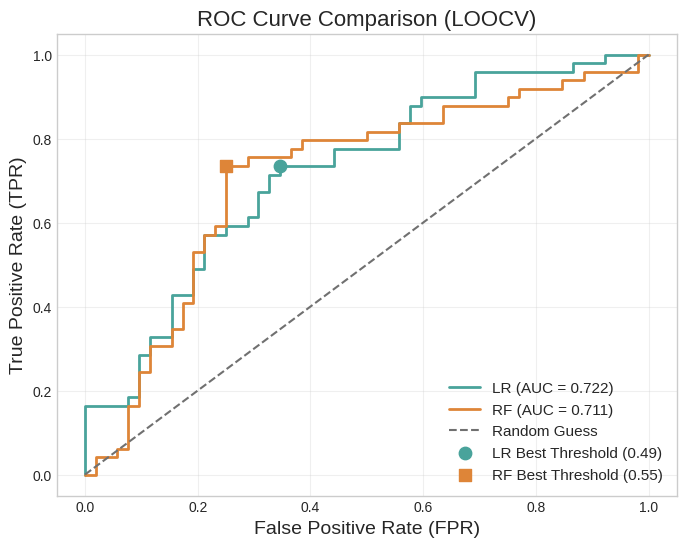

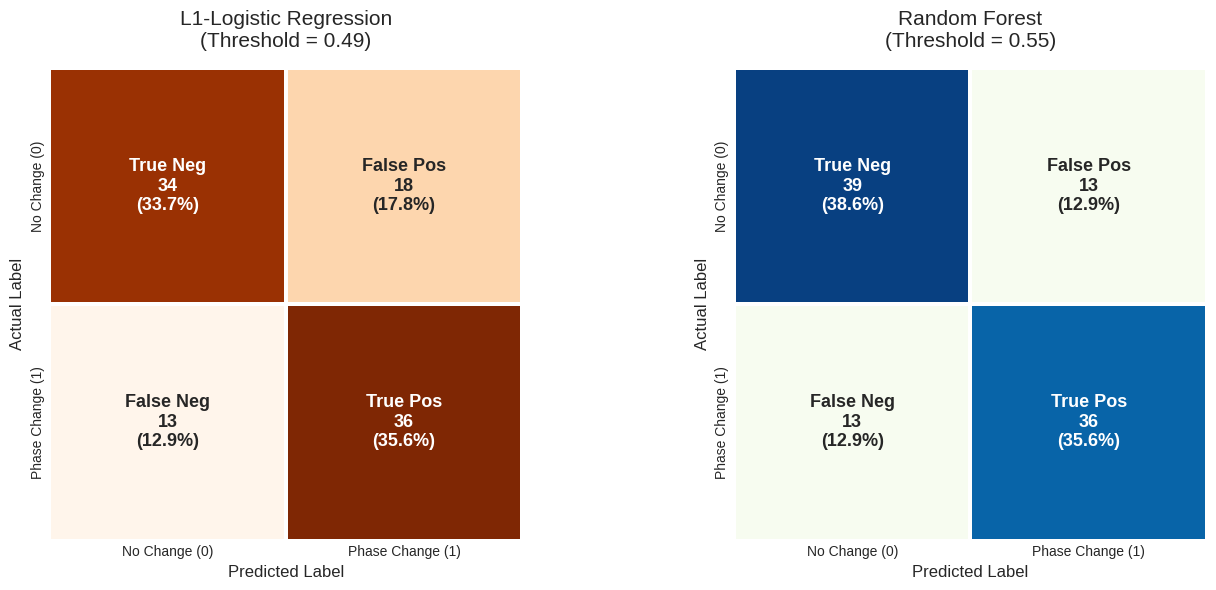

In [6]:
# ==========================================
# Cell 4: Model Comparison & Visualizations
# ==========================================
print("Generating comparison plots...")

# --- 1. ROC Curves ---
plt.figure(figsize=(8, 6))


plt.plot(fpr_lr, tpr_lr, color='#49A39B', lw=2, label=f'LR (AUC = {roc_auc_lr:.3f})')
plt.plot(fpr_rf, tpr_rf, color='#DE8538', lw=2, label=f'RF (AUC = {roc_auc_rf:.3f})')
plt.plot([0, 1], [0, 1], color='#707070', lw=1.5, linestyle='--', label='Random Guess')

plt.scatter(fpr_lr[best_idx_lr], tpr_lr[best_idx_lr], s=80, c='#49A39B', marker='o', zorder=10,
            label=f'LR Best Threshold ({best_threshold_lr:.2f})')

plt.scatter(fpr_rf[best_idx_rf], tpr_rf[best_idx_rf], s=80, c='#DE8538', marker='s', zorder=10,
            label=f'RF Best Threshold ({best_threshold_rf:.2f})')

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=14)
plt.ylabel('True Positive Rate (TPR)', fontsize=14)
plt.title('ROC Curve Comparison (LOOCV)', fontsize=16)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.savefig('roc_comparison.png', dpi=600, bbox_inches='tight')
plt.show()

# --- 2. Confusion Matrix ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
models_preds = [('L1-Logistic Regression', y_pred_lr, 'Oranges'),
                ('Random Forest', y_pred_rf, 'GnBu')]

for ax, (title, preds, cmap) in zip(axes, models_preds):
    cm = confusion_matrix(y, preds, labels=[0, 1])
    group_names = ['True Neg', 'False Pos', 'False Neg', 'True Pos']
    group_counts = [f"{value:0.0f}" for value in cm.flatten()]
    group_percentages = [f"{value:.1%}" for value in cm.flatten()/np.sum(cm)]
    labels = [f"{v1}\n{v2}\n({v3})" for v1, v2, v3 in zip(group_names, group_counts, group_percentages)]
    labels = np.asarray(labels).reshape(2, 2)

    sns.heatmap(cm, annot=labels, fmt='', cmap=cmap, cbar=False, ax=ax,
                xticklabels=['No Change (0)', 'Phase Change (1)'],
                yticklabels=['No Change (0)', 'Phase Change (1)'],
                annot_kws={"size": 13, "weight": "bold"}, square=True, linewidths=1.5, linecolor='white')

    if 'Logistic' in title:
        ax.set_title(f"{title}\n(Threshold = {best_threshold_lr:.2f})", fontsize=15, pad=15)
    else:
        ax.set_title(f"{title}\n(Threshold = {best_threshold_rf:.2f})", fontsize=15, pad=15)

    ax.set_ylabel('Actual Label', fontsize=12)
    ax.set_xlabel('Predicted Label', fontsize=12)

plt.tight_layout()
plt.savefig('confusion_matrices_comparison.png', dpi=600, bbox_inches='tight')
plt.show()